In [9]:
import truststore

truststore.inject_into_ssl()

In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

NON LLM WORKFLOW

In [11]:
# define state


class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [12]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight_kg"]
    height = state["height_m"]

    bmi = weight / (height**2)
    state["bmi"] = round(bmi, 2)

    return state

In [13]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    category = None

    if bmi < 18:
        category = "under_weight"
    elif bmi <= 25:
        category = "fit"
    else:
        category = "overweight"

    state["category"] = category
    return state

In [14]:
# define graph
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("label_bmi", label_bmi)

# add edges to graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi", END)

# compile the graph
workflow = graph.compile()

In [15]:
# execute the graph
initial_state = {"weight_kg": 80, "height_m": 1.73}
final_state = workflow.invoke(initial_state)

final_state

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'overweight'}

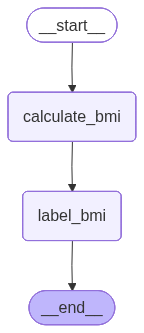

In [16]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

LLM WORKFLOW

In [17]:
from dotenv import load_dotenv

load_dotenv()

True

In [25]:
from langchain_groq import ChatGroq

model = ChatGroq(model="llama-3.3-70b-versatile", temperature=1)

In [26]:
class LLMState(TypedDict):
    question: str
    answer: str

In [27]:
def llm_qa(state: LLMState) -> LLMState:
    question = state["question"]
    prompt = f"Answer the following question {question}"
    answer = model.invoke(prompt).content
    state["answer"] = answer
    return state

In [28]:
# define graph
graph = StateGraph(LLMState)

# add nodes to graph
graph.add_node("llm_qa", llm_qa)

# add edges to graph
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

# compile the graph
workflow = graph.compile()

In [30]:
initial_state = {"question": "What is temerature in RAG"}
final_state = workflow.invoke(initial_state)
final_state["answer"]

'In the context of Risk Assessment and Governance (RAG), temperature is not directly related to the physical concept of temperature. Instead, RAG is often associated with a risk assessment methodology that uses a color-coded system, typically:\n\n* Red (R): High-risk or critical issues\n* Amber (A): Medium-risk or cautionary issues\n* Green (G): Low-risk or acceptable issues\n\nIn this context, the term "temperature" might be used metaphorically to describe the level of risk or the \'heat\' of an issue, with higher temperatures indicating higher risk levels. However, this is not a direct reference to physical temperature. If you have any more specific information or context about the term "temperature" in RAG, I\'d be happy to try and provide further clarification.'

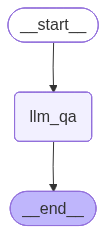

In [31]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

Prompt Chaining

In [32]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [33]:
def create_outline(state: BlogState) -> BlogState:
    title = state["title"]
    prompt = f"Generate an outline for a blog on the topic - {title}"
    state["outline"] = model.invoke(prompt).content
    return state

In [34]:
def create_blog(state: BlogState) -> BlogState:
    title = state["title"]
    outline = state["outline"]
    prompt = f"Write a detailed blog on the title - {title} using the following outline \n {outline}"
    state["content"] = model.invoke(prompt).content
    return state

In [35]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

workflow = graph.compile()

In [36]:
initial_state = {"title": "Indian food"}
final_state = workflow.invoke(initial_state)
final_state

{'title': 'Indian food',
 'outline': "Here's a suggested outline for a blog on Indian food:\n\n**I. Introduction**\n  * Brief overview of Indian cuisine\n  * Importance of food in Indian culture\n  * Purpose of the blog post\n\n**II. History and Evolution of Indian Food**\n  * Origins of Indian cuisine\n  * Influence of various empires and cultures (Mughal, British, etc.)\n  * Regional variations and their unique characteristics\n\n**III. Popular Indian Dishes**\n  * Overview of popular Indian dishes (e.g. curries, tandoori, biryani)\n  * Examples of popular dishes from different regions (e.g. South Indian dosas, North Indian naan)\n  * Description of common ingredients used in Indian cooking (e.g. spices, basmati rice, naan)\n\n**IV. Regional Indian Cuisines**\n  * Overview of different regional cuisines in India (e.g. North Indian, South Indian, East Indian, West Indian)\n  * Characteristics and popular dishes of each region\n  * Examples of local ingredients and cooking techniques u

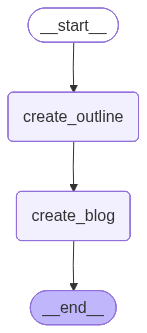

In [37]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())